Added SNR estimate as 4th output channel

Also training on more difficult data: 
- d0.00-0.80
- added +/- 5 deg rotation to pipette
- more background noise


**Performance:** 

**Model:**
ImageNet1k_v2
- training resnet [-2][-2:] and [-1]
- adaptive avg pooling layer
- one dense layer with xyzw output

**Training:**
- Batch size 96
- MSE loss
- Adam, learning rate 0.001


In [1]:
import numpy as np
from training_data import load_training_data
import matplotlib.pyplot as plt

In [2]:
save_path = "torch_models/04_more_increased_difficulty.pth"
training_data_path = "training_data"

In [3]:
all_training_data = load_training_data(training_data_path)
levels = list(all_training_data.levels.keys())
print(levels)

['d0.00', 'd0.20', 'd0.40', 'd0.60', 'd0.80']


In [4]:

# Build a pytorch model consisting of:
# - a resnet101v2 pretrained on imagenet, excluding its final classification layer
#    (the final layer has output shape (batch_size, M, N, channels)
# - a max pooling layer that takes the maximum only over channels (output shape (batch_size, M, N))
# - a dense layer with 3 one-hot outputs (output shape (batch_size, 3, onehot_size))

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

print("CUDA:", torch.cuda.is_available())

class PipetteDetector(nn.Module):
    def __init__(self):
        super(PipetteDetector, self).__init__()
        resnet101 = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        self.resnet = torch.nn.Sequential(*(list(resnet101.children())[:-2]))

        # freeze all parameters in the resnet
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # unfreeze the last block (10 layers)
        # for param in self.resnet[-1][-1].parameters():
        #     param.requires_grad = True

        # unfreeze thelast 9th-4rd blocks (60 layers) 
        for i in range(6):
            for param in self.resnet[-2][-i].parameters():
                param.requires_grad = True
        
        # unfreeze the last 3 blocks (30 layers)
        for param in self.resnet[-1].parameters():
            param.requires_grad = True
            
        # global average pooling 2d
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        # self.pooling = nn.AdaptiveMaxPool2d((1, 1))

        self.xyzw_out = nn.LazyLinear(4)

    def forward(self, input):
        resnet_output = self.resnet(input)

        pooled = self.pooling(resnet_output)

        flat = pooled.reshape(pooled.size(0), -1)

        xyzw = self.xyzw_out(flat)
        return xyzw
    
# initialize a model just to see its structure
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CUDA: True


In [5]:
from torchsummary import summary
test_model = PipetteDetector()
test_model.to(device);
# print(model)
summary(test_model, input_size=(3, 400, 400))

del test_model
torch.cuda.empty_cache()


/home/luke/pipette-detection/conda_env/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 200, 200]           9,408
       BatchNorm2d-2         [-1, 64, 200, 200]             128
              ReLU-3         [-1, 64, 200, 200]               0
         MaxPool2d-4         [-1, 64, 100, 100]               0
            Conv2d-5         [-1, 64, 100, 100]           4,096
       BatchNorm2d-6         [-1, 64, 100, 100]             128
              ReLU-7         [-1, 64, 100, 100]               0
            Conv2d-8         [-1, 64, 100, 100]          36,864
       BatchNorm2d-9         [-1, 64, 100, 100]             128
             ReLU-10         [-1, 64, 100, 100]               0
           Conv2d-11        [-1, 256, 100, 100]          16,384
      BatchNorm2d-12        [-1, 256, 100, 100]             512
           Conv2d-13        [-1, 256, 100, 100]          16,384
      BatchNorm2d-14        [-1, 256, 1

In [6]:
# prepare training data
from training_data import Normalizer

# decide how to transform data
class Normalizer:
    """Used to normalize and denormalize position+snr data.
    
    Input data should be a 1D numpy array with 4 elements: (z, row, col, snr)
    (z, row, col_) values are scaled and shifted to be in the range [-1, 1]
    snr is log-transformed
    """
    def __init__(self, pos_min, pos_max):
        range = np.array([pos_min+[-1], pos_max+[1]])
        diff = range[1] - range[0]
        self.scale = 2 / diff
        self.offset = range[0] + diff / 2

    def normalize(self, x):
        xn = (x - self.offset) * self.scale
        xn[:, 3] = np.log10(xn[:, 3] + 1)
        assert np.all(np.isfinite(xn))
        return xn

    def denormalize(self, x):
        x = (x / self.scale) + self.offset
        x[:, 3] = 10**(x[:, 3]) - 1
        return x

pos_min = [-100, 0, 0]
pos_max = [100, 500, 500]
pos_normalizer = Normalizer(pos_min, pos_max)

def make_image_tensor(data):
    """Convert ubyte image data to a 0.0-1.0 float32 torch tensor on the GPU."""
    normalized = (data / 255).transpose((0, 3, 1, 2)).astype(np.float32)
    return torch.tensor(normalized).to(device)

def make_position_tensor(data):
    """Convert position data to a normalized (-0.5 to 0.5) float32 torch tensor on the GPU."""
    return torch.tensor(pos_normalizer.normalize(data).astype(np.float32)).to(device)

batch_size = 96
# data_generator = training_data.generator(batch_size)
# data_generator yields batches of (image, position) data
#  - images are 3D numpy arrays of shape (batch_size, height, width), with values in [0, 255]
#  - positions are 2D numpy arrays of shape (batch_size, (z, y, x)), with z values in microns and x, y in pixels 

# split the data into training and validation sets
validation_size = 400
training_data, validation_data = all_training_data.split([
    1 - validation_size / len(all_training_data), 
    validation_size / len(all_training_data)
])
v_img, v_pos = validation_data.get_arrays()
validation_images = make_image_tensor(v_img)
validation_positions = make_position_tensor(v_pos)

In [7]:
# initialize the model
model = PipetteDetector()
model.to(device)

# Define a loss function and optimizer
criterion = nn.MSELoss()  # for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)



In [8]:

class TrainingHistory:
    def __init__(self):
        self.history = {'i': [], 'loss': []}

    def append(self, i, prediction, target, loss):
        self.history['i'].append(i)
        self.history['loss'].append(loss)
        result = TrainingHistory.analyze_prediction(prediction, target)
        for k,v in result.items():
            if k not in self.history:
                self.history[k] = []
            self.history[k].append(v)

    def __getitem__(self, key):
        return np.array(self.history[key])
    
    def plot(self, loss_ax, accuracy_ax, label=None):
        alpha = 1.0 if 'validat' in label else 0.5
        loss_ax.plot(self.history['i'], self.history['rmse_xy'], label=label+' xy RMSE', color=(0, 0.7, 0), alpha=alpha)
        loss_ax.plot(self.history['i'], self.history['rmse_z'], label=label+' z RMSE', color=(0.7, 0, 0), alpha=alpha)
        loss_ax.plot(self.history['i'], self.history['rmse_snr'], label=label+' snr RMSE', color=(0, 0, 0.7), alpha=alpha)
        loss_ax.set_yscale('log')
        loss_ax.legend()
        accuracy_ax.plot(self.history['i'], self.history['accuracy_xy'], label=label+' xy accuracy', color=(0, 0.7, 0), alpha=alpha)
        accuracy_ax.plot(self.history['i'], self.history['accuracy_z'], label=label+' z accuracy', color=(0.7, 0, 0), alpha=alpha)
        accuracy_ax.set_ylim(0, 1)
        accuracy_ax.legend()

    @staticmethod
    def analyze_prediction(predicted_pos, target_pos, radius=0.02):
        predicted_pos = predicted_pos.cpu().detach().clone().numpy()
        target_pos = target_pos.cpu().detach().clone().numpy()
        predicted_z_sign = np.sign(predicted_pos[:, 0])
        target_z_sign = np.sign(target_pos[:, 0])
        result = {
            'rmse_xy': ((predicted_pos - target_pos)[:, 1:3]**2).mean()**0.5,
            'rmse_z': ((predicted_pos - target_pos)[:, 0]**2).mean()**0.5,
            'rmse_snr': ((predicted_pos - target_pos)[:, 3]**2).mean()**0.5,
            'n_correct_xy': (((predicted_pos - target_pos)[:, 1:3]**2).sum(axis=1)**0.5 < radius).sum(),
            'n_correct_z': (predicted_z_sign == target_z_sign).sum(),
            'batch_size': predicted_pos.shape[0],
        }
        result['accuracy_xy'] = result['n_correct_xy'] / result['batch_size']
        result['accuracy_z'] = result['n_correct_z'] / result['batch_size']
        return result


## Train the model

In [ ]:
training_history = TrainingHistory()
validation_history = TrainingHistory()
try:
    model.train()  # set model to training mode
    for i, data in enumerate(data_generator):
        # inputs is a 4D numpy array of shape (batch_size, height, width, channels), normalized to [0, 1]
        # labels is a 2D numpy array of shape (batch_size, 3), normalized using training_data.output_norm
        inputs, labels = data
        image_tensor = make_image_tensor(inputs)
        position_tensor = make_position_tensor(labels)

        # zero the parameter gradients (otherwise they accumulate)
        optimizer.zero_grad()

        # run model, calculate loss, and backpropagate
        output = model(image_tensor)
        loss = criterion(output, position_tensor)
        loss.backward()
        optimizer.step()
        # scheduler.step()

        # track performance over time
        training_history.append(i, output, position_tensor, loss.item())
        del image_tensor, position_tensor, output, loss
        torch.cuda.empty_cache()

        if i % 10 == 9:
            with torch.no_grad():
                val_output = model(validation_images)
                val_loss = criterion(val_output, validation_positions)
                validation_history.append(i, val_output, validation_positions, val_loss.item())

            recent_size = 10
            training_loss = training_history['loss'][-recent_size:]
            training_accuracy = training_history['accuracy_xy'][-recent_size:].mean()
            val_loss = validation_history['loss'][-1]
            validation_accuracy = validation_history['accuracy_xy'][-1]
            validation_z_accuracy = validation_history['accuracy_z'][-1]
            print(
                f'[step {i:06d}] avg sqrt loss: {(training_loss**0.5).mean():0.6f}\n'
                f'              final sqrt loss: {training_loss[-1]**0.5:0.6f}\n'
                f'              val sqrt loss: {val_loss**0.5:0.6f}\n'
                f'              val xy rmse: {validation_history["rmse_xy"][-1]:0.6f}\n'
                f'              val z rmse: {validation_history["rmse_z"][-1]:0.6f}\n'
                f'              val snr rmse: {validation_history["rmse_snr"][-1]:0.6f}\n'
                f'              training xy accuracy: {100 * training_accuracy:0.2f}%\n'
                f'              validation xy accuracy: {100 * validation_accuracy:0.2f}%\n'
                f'              validation z accuracy: {100 * validation_z_accuracy:0.2f}%\n'
            )
            del val_output, val_loss
            torch.cuda.empty_cache()
            
        if i % 100 == 99:
            print("Saving model..")
            torch.save(model.state_dict(), save_path)

except KeyboardInterrupt:
    print('Interrupted, saving..')
    torch.save(model.state_dict(), save_path)

print('Finished Training')

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
training_history.plot(ax[0], ax[1], label='training')
validation_history.plot(ax[0], ax[1], label='validation')


In [11]:
# reload model weights
model.load_state_dict(torch.load(save_path))

<All keys matched successfully>

## Check against training data

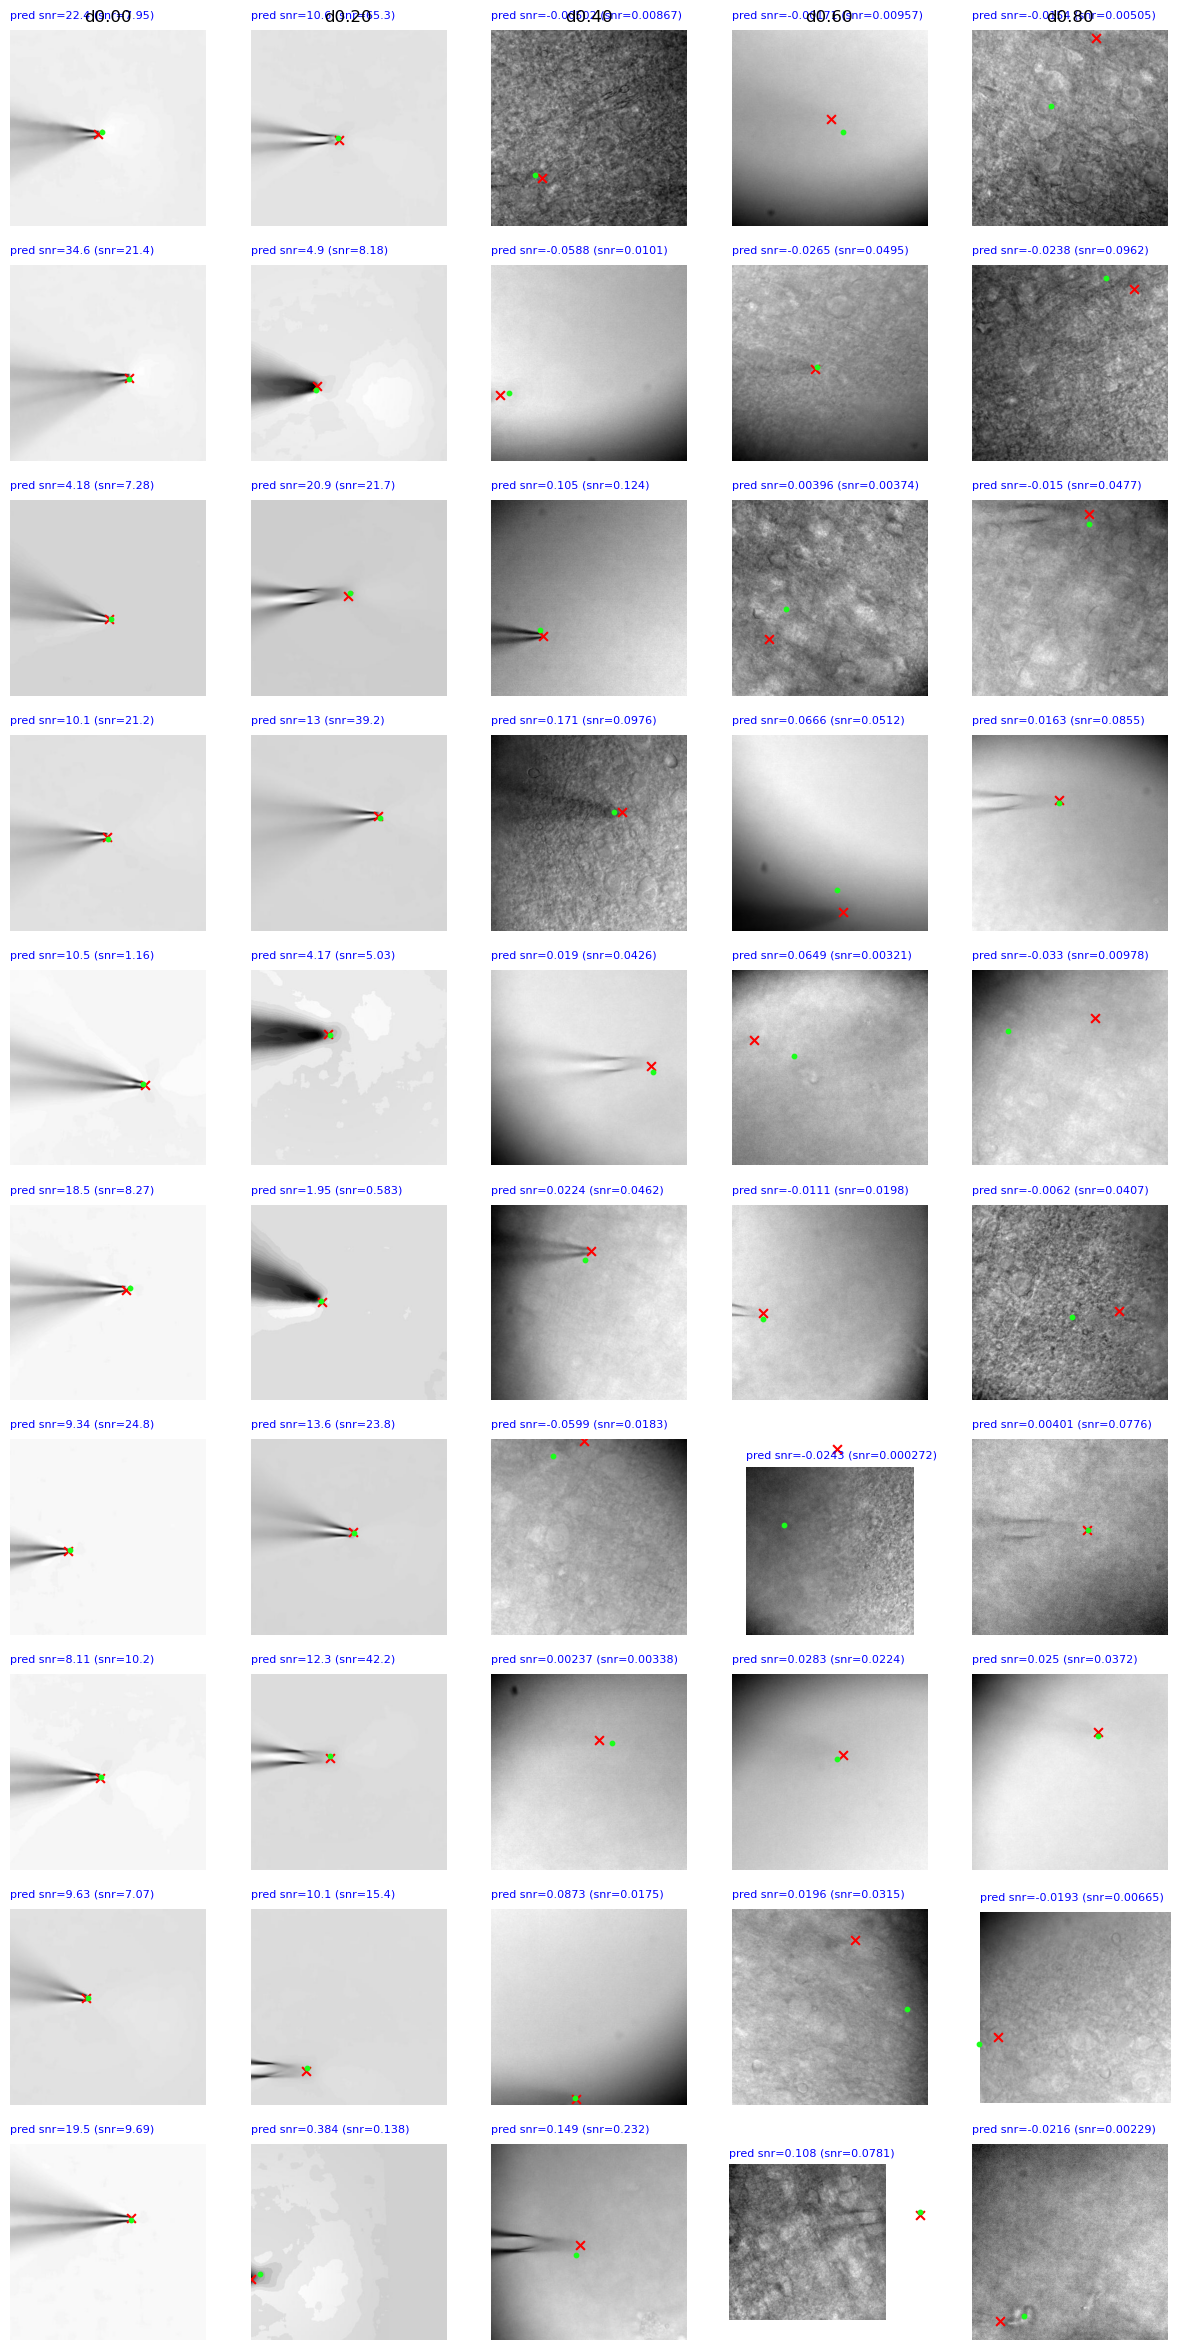

In [12]:
shape = (10, len(training_data.levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))
for i,level in enumerate(training_data.levels):
    ax[0, i].set_title(level)


n_examples = 100
predictions = {}
for col,level in enumerate(training_data.levels):
    training_level = training_data.get_level(level)
    image, pip_pos = training_level[:n_examples].get_arrays()
    # inds = np.arange(len(image))
    # np.random.shuffle(inds)
    # image = image[inds]
    # pip_pos = pip_pos[inds]

    # pip_pos = training_data.output_norm.denormalize(pip_pos)
    # use model in inference mode to make prediction from image
    model.eval()  # set model to inference mode
    with torch.no_grad():
        image_tensor = make_image_tensor(image)
        pred = model(image_tensor).cpu().numpy()
        pred = pos_normalizer.denormalize(pred)
    
    predictions[level] = {'image': image, 'pip_pos': pip_pos, 'pred': pred}
    # select shape[0] random examples to plot
    inds = np.random.choice(n_examples, shape[0], replace=False)
    for row,ind in enumerate(inds):
        axi = ax[row, col]
        # pred = training_data.output_norm.denormalize(model.model.predict(image))
        axi.imshow(image[ind], cmap='gray')
        axi.scatter(pip_pos[ind, 2], pip_pos[ind, 1], color='red', s=40, marker='x')
        axi.scatter(pred[ind, 2], pred[ind, 1], color=(0.1, 1.0, 0.1), s=10)
        snr_str = f'pred snr={pred[ind, 3]:0.3g} (snr={pip_pos[ind, 3]:0.3g})'
        axi.axis('off')
        # add text
        axi.text(0, -40, snr_str, fontsize=8, color='blue', verticalalignment='top')



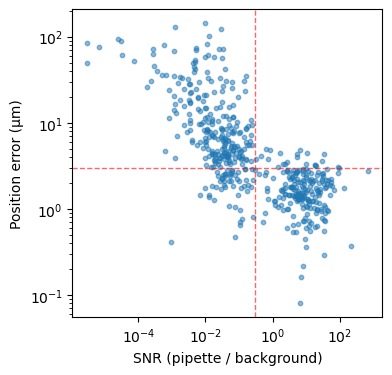

In [13]:
levels = []
pip_pos = []
pred = []
for level in predictions:
    levels.append([level]*n_examples)
    pip_pos.append(predictions[level]['pip_pos'])
    pred.append(predictions[level]['pred'])
pip_pos = np.concatenate(pip_pos)
pred = np.concatenate(pred)
# calculate position error in microns
m_per_px = 3.23e-07  # taken from template source data
pos_error = 1e6 * m_per_px * ((pred - pip_pos)[:, 1:3]**2).sum(axis=1)**0.5

# scatter plot error vs snr
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(pip_pos[:, 3], pos_error, s=10, alpha=0.5) 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('SNR (pipette / background)')
ax.set_ylabel('Position error (μm)')
ax.axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(0.3, color='red', linestyle='--', alpha=0.6, linewidth=1)

## Check against test data

In [14]:
from test_data import load_test_datasets

In [15]:
test_data = load_test_datasets()

/mp0/d/data/autopatch_test/2024.02.22_000/slice_001/cell_005/video_000.ma
/mp0/d/data/autopatch_test/2024.02.22_000/slice_001/cell_003/video_000.ma
/mp0/d/data/autopatch_test/2024.01.24_000/slice_002/cell_008/video_000.ma
/mp0/d/data/autopatch_test/2024.01.24_000/slice_002/cell_008/video_001.ma
/mp0/d/data/autopatch_test/2024.02.22_000/slice_001/cell_005/video_002.ma


In [16]:
for test_ds in test_data:
    img = test_ds['rotated_data']
    image_tensor = make_image_tensor(img)
    model.eval()  # set model to inference mode
    with torch.no_grad():
        pred = model(image_tensor).cpu().numpy()
    test_ds['pred'] = pos_normalizer.denormalize(pred)


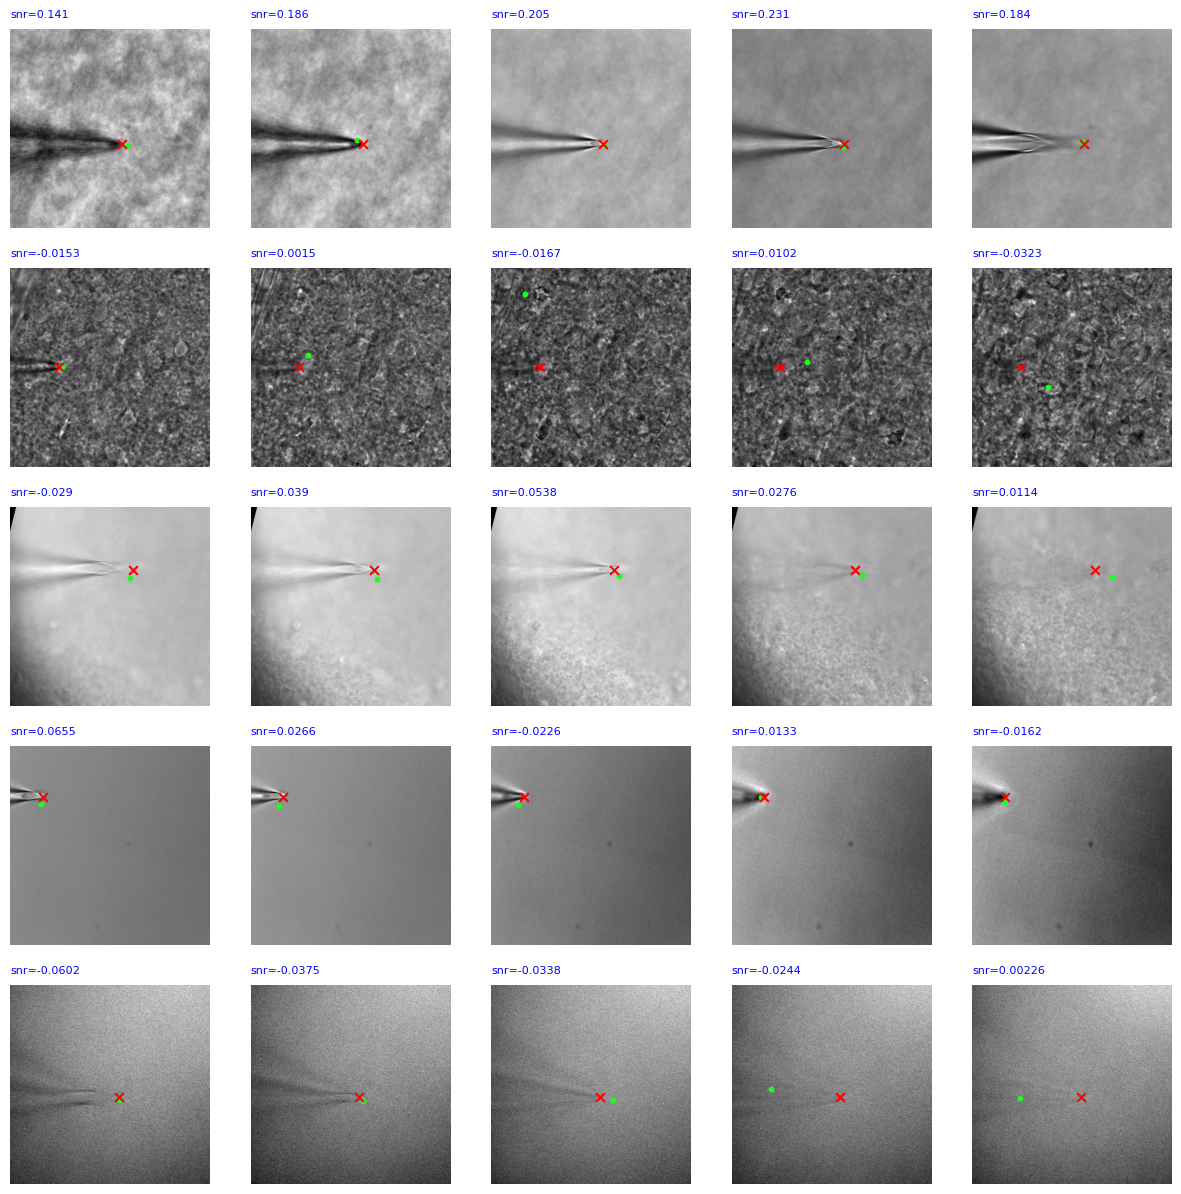

In [17]:
fig, ax = plt.subplots(len(test_data), 5, figsize=(15, 3*len(test_data)))
for i,test_ds in enumerate(test_data):
    img = test_ds['rotated_data']
    pred = test_ds['pred']
    inds = np.linspace(0, len(img)-1, 7).astype(int)[1:-1]

    for j,ind in enumerate(inds):
        ax[i, j].imshow(img[ind, ..., 0], cmap='gray')
        ax[i, j].scatter(pred[ind, 2], pred[ind, 1], color=(0.1, 1.0, 0.1), s=10)
        ax[i, j].scatter(test_ds['rotated_position'][1], test_ds['rotated_position'][0], color='red', s=40, marker='x')
        ax[i, j].axis('off')
        snr_str = f'snr={pred[ind, 3]:0.3g}'
        ax[i, j].text(0, -40, snr_str, fontsize=8, color='blue', verticalalignment='top')

    


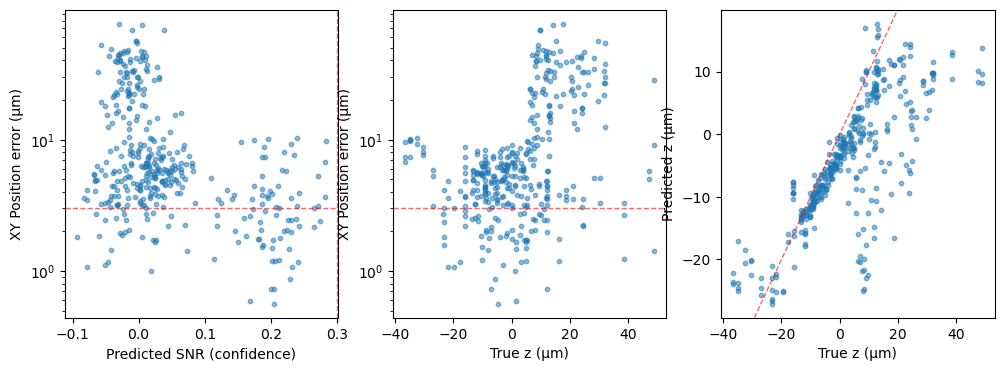

In [18]:
pred = np.concatenate([test_ds['pred'] for test_ds in test_data])
pred_xy = pred[:, 1:3]
true_xy = np.concatenate([[test_ds['rotated_position']]*len(test_ds['pred']) for test_ds in test_data])
pred_z = pred[:, 0]
true_z = 1e6 * np.concatenate([test_ds['z'] for test_ds in test_data])
pred_snr = pred[:, 3]


# calculate position error in microns
m_per_px = 3.23e-07  # taken from template source data
xy_err = 1e6 * m_per_px * ((pred_xy - true_xy)**2).sum(axis=1)**0.5
z_err = (pred_z - true_z)**2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].scatter(pred_snr, xy_err, s=10, alpha=0.5)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Predicted SNR (confidence)')
ax[0].set_ylabel('XY Position error (μm)')
ax[0].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax[0].axvline(0.3, color='red', linestyle='--', alpha=0.6, linewidth=1)

ax[1].scatter(true_z, xy_err, s=10, alpha=0.5)
ax[1].set_yscale('log')
ax[1].set_xlabel('True z (μm)')
ax[1].set_ylabel('XY Position error (μm)')
ax[1].axhline(3, color='red', linestyle='--', alpha=0.6, linewidth=1)

ax[2].scatter(true_z, pred_z, s=10, alpha=0.5)
# ax[2].set_yscale('log')
ax[2].set_xlabel('True z (μm)')
ax[2].set_ylabel('Predicted z (μm)')
ax[2].axline((0, 0), slope=1, color='red', linestyle='--', alpha=0.6, linewidth=1)
